In [22]:
import numpy as np
import json
import torch
from pathlib import Path

from src.models.model_utilizer import load_net
from src.dataloaders.ZerosPolesDataset import ConversionTransforms
from usecases.utils.test_nb_functions import zeros_poles_freq_to_positions, plot_responses, mask_postprocess

In [23]:
if torch.cuda.is_available():
    print("CUDA is available!")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version used by PyTorch: {torch.version.cuda}")
    v = torch.backends.cudnn.version()
    print(f"cuDNN: {v//10000}.{(v%1000)//100}.{v%100}")
else:
    print("CUDA is not available. PyTorch is using CPU.")

CUDA is available!
Number of GPUs: 1
Current GPU Name: NVIDIA GeForce RTX 3060
CUDA Version used by PyTorch: 12.6
cuDNN: 9.5.1


In [24]:
'''
filename = "Zouti_300_AP"
tmp = np.loadtxt(sample_dir / (filename + '.dat'), skiprows=1)
headers = "Frequency (Hz), Gain (dB), Phase (rad)"
np.savetxt(filename + '.csv', tmp, 
           delimiter=',', 
           fmt='%.2E',
           header=headers,
           comments='')
'''

'\nfilename = "Zouti_300_AP"\ntmp = np.loadtxt(sample_dir / (filename + \'.dat\'), skiprows=1)\nheaders = "Frequency (Hz), Gain (dB), Phase (rad)"\nnp.savetxt(filename + \'.csv\', tmp, \n           delimiter=\',\', \n           fmt=\'%.2E\',\n           header=headers,\n           comments=\'\')\n'

Выбор модели.

In [25]:
model_name = 'TransformerBottleneck-model'
log_name = 'TransformerBottleneck-model_preactivation_verynoisy_kernel_5_bce_50'
from src.models.TransformerBottleneck_model import TransformerBottleneck_model as user_model

Пути к каталогам.

In [26]:
config_dir = Path("./src/config/")

config_path = config_dir / "config.json"
assert config_path.exists(), f"Config not found: {config_path}"
with open(config_path, "r") as f:
    general_config = json.load(f)

checkpoints_dir = Path(general_config['checkpoints_dir'])
logs_dir = Path(general_config['logs_dir'])

model_log_path = logs_dir / f"{log_name}.json"
assert model_log_path.exists(), f"Config not found: {model_log_path}"
with open(model_log_path, "r") as f:
    model_log = json.load(f)

train_log = model_log["train_log"]
best_epoch = model_log["summary"]["best_epoch"]

Импорт модели.

In [27]:
device = torch.device(general_config["device"].lower() if torch.cuda.is_available() else 'cpu')

model = user_model(
    in_channels = 4,
    out_channels = 4,
    features = model_log["metadata"]["model"]["feature_list"]
    )

model = model.to(device)
model, _, _, _ = load_net(
    net = model,
    checkpoints_file = checkpoints_dir / f"best_{model_name}.pth",
    device = device
    )

model.eval()

transform = ConversionTransforms(
    num_iter=2,
    return_input=False
    )

Restoring checkpoint:  checkpoints\best_TransformerBottleneck-model.pth


## Чтение данных из csv-файлов

Настройки на инференс данных эксперимента.

In [28]:
'''
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")
sample_file_name_list = [
    "Zout_300_AP",
    "Zouti_300_AP",
    "Wui_300_DP",
    "Wui_delay_300_DP",
    "G_I_PID_300_DP",
    "G_U_PI_300_DP",
    "G_I_PI_300_DP"
    ]
interp_flag = True
positions_flag = False
'''

'\nsample_dir = Path("usecases/test_samples/experiments_13_May_2026")\nsample_file_name_list = [\n    "Zout_300_AP",\n    "Zouti_300_AP",\n    "Wui_300_DP",\n    "Wui_delay_300_DP",\n    "G_I_PID_300_DP",\n    "G_U_PI_300_DP",\n    "G_I_PI_300_DP"\n    ]\ninterp_flag = True\npositions_flag = False\n'

Настройки на инференс примеров из тестового набора данных.

In [29]:

sample_dir = Path("usecases/test_samples/very_noisy/")
sample_file_name_list = None
interp_flag = False
positions_flag = True


In [30]:
data_list = []

In [31]:
ext = '.csv'

if sample_file_name_list is None:
    sample_file_name_list = [f.stem for f in sample_dir.glob('*'+ext)]

for sample_file_name in sample_file_name_list:
    data_list.append(np.loadtxt(sample_dir / (sample_file_name + ext), delimiter=',', skiprows=1).T)

Координаты нулей/полюсов.

In [32]:
if positions_flag:
    zeros_poles_positions_path = sample_dir/ "test_masks.json"
    assert zeros_poles_positions_path.exists(), f"Config not found: {zeros_poles_positions_path}"
    with open(zeros_poles_positions_path, "r") as f:
        zeros_poles_positions_full = json.load(f)
    zeros_poles_positions_list = []
    for sample_file_name in sample_file_name_list:
        zeros_poles_positions_list.append(zeros_poles_positions_full[sample_file_name])

    for zeros_poles_positions in zeros_poles_positions_list:
        zeros_poles_positions.pop('zero_poles')

    zeros_poles_list = zeros_poles_positions_list.copy()
else:
    zeros_poles_freq_list = [
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": []
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": []
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": [5.5e3]
        },
        {
        "left_poles": [39],
        "right_poles": [],
        "left_zeros": [25e3],
        "right_zeros": [5.5e3]
        },
        {
        "left_poles": [42e3],
        "right_poles": [],
        "left_zeros": [380, 17e3],
        "right_zeros": []
        },
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [270],
        "right_zeros": []
        },
        {
        "left_poles": [],
        "right_poles": [],
        "left_zeros": [1.5e3],
        "right_zeros": []
        }
    ]
    zeros_poles_list = zeros_poles_freq_list.copy()

Интерполяция данных (по требованию).

In [33]:
if interp_flag:
    data_list_interp = []
    for data in data_list:
        freq = data[0,:]
        mag_ph = np.array([data[1,:], data[2,:]])

        freq_log = np.logspace(np.log10(freq.min()), np.log10(freq.max()), num=512)
        mag_ph_interp = np.array([np.interp(freq_log, freq, y) for y in mag_ph])
        data_interp = np.vstack((freq_log, mag_ph_interp))
        data_list_interp.append(data_interp)
    data_list = data_list_interp.copy()

Инференс.

In [34]:
mask_threshold = model_log["metadata"]["model"]["mask_threshold"]

predictions_list = []
for data in data_list:
        inputs = torch.from_numpy(np.ascontiguousarray(transform(data), dtype=np.float32))
        with torch.no_grad():
                logits = model(inputs.unsqueeze(0).to(device))
                predictions_list.append((torch.sigmoid(logits.squeeze(0)) > mask_threshold).float().detach().cpu().numpy())

## Визуализация

In [35]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

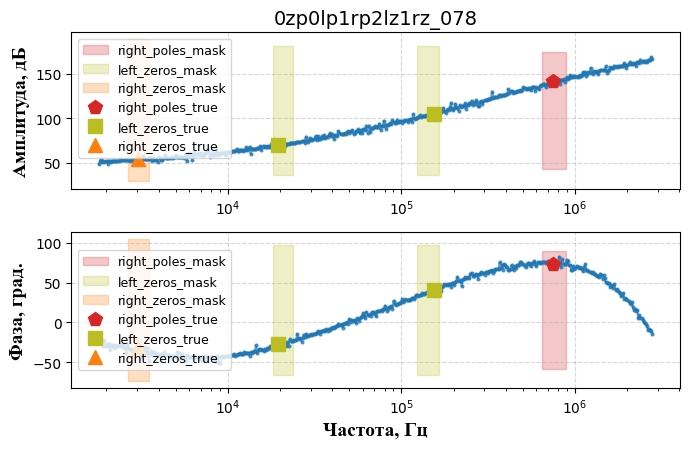

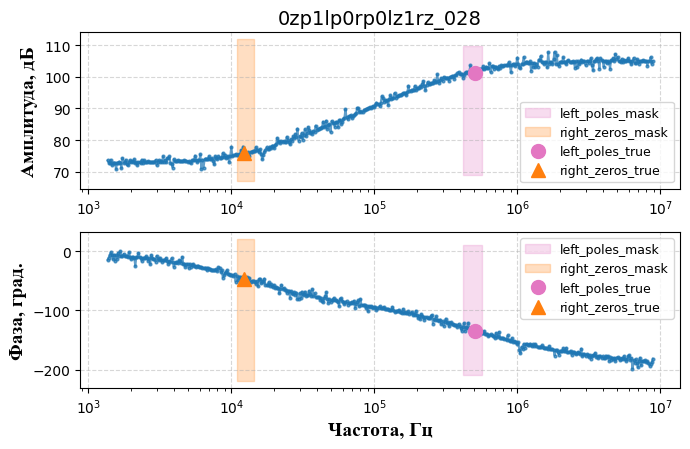

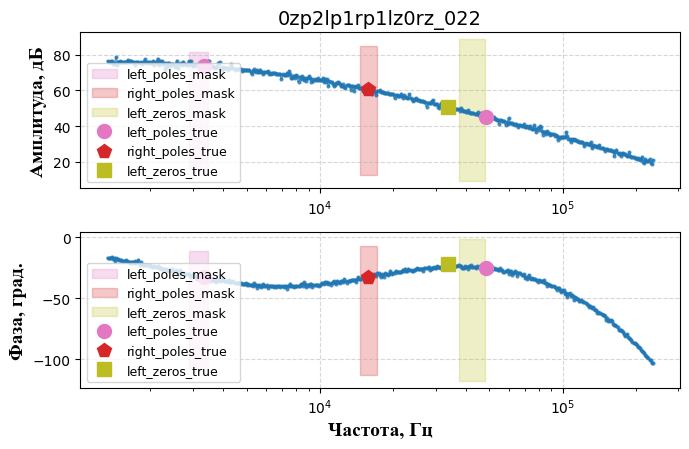

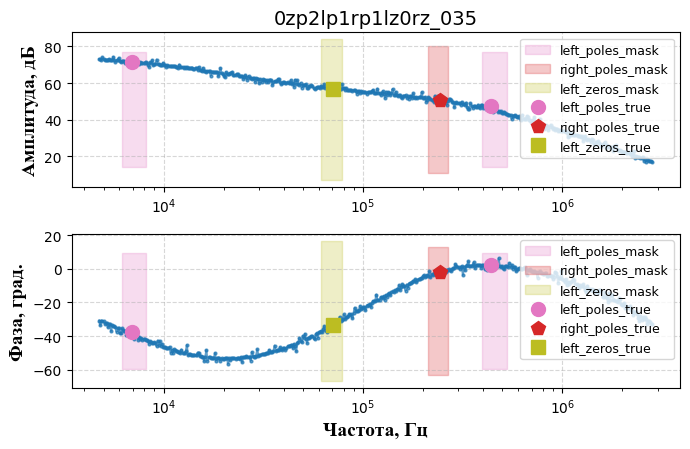

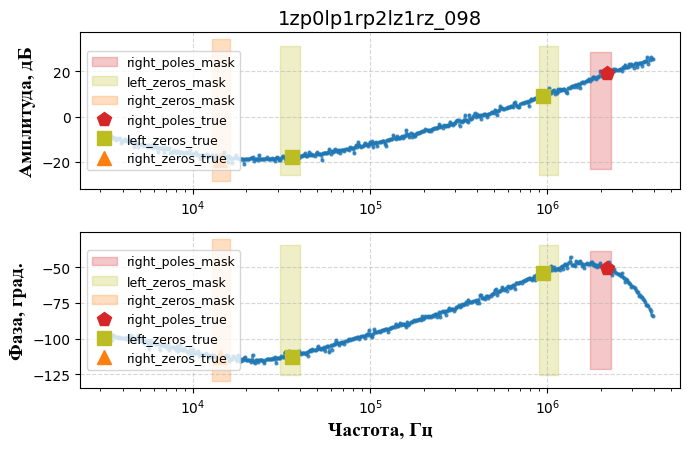

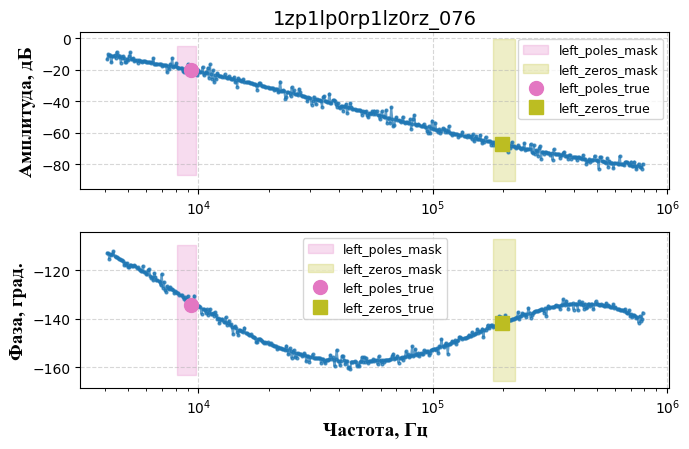

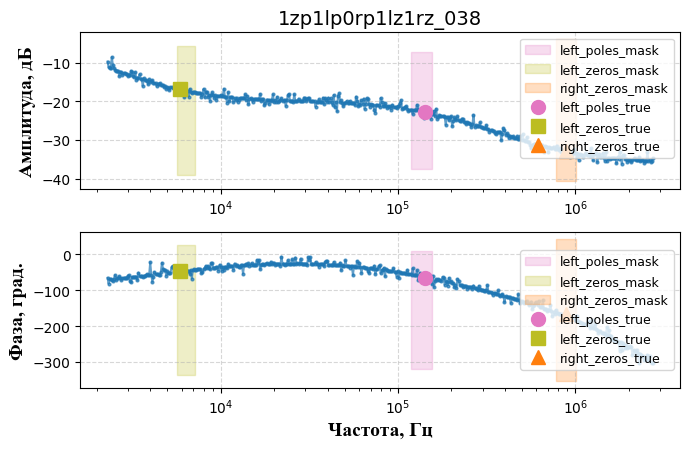

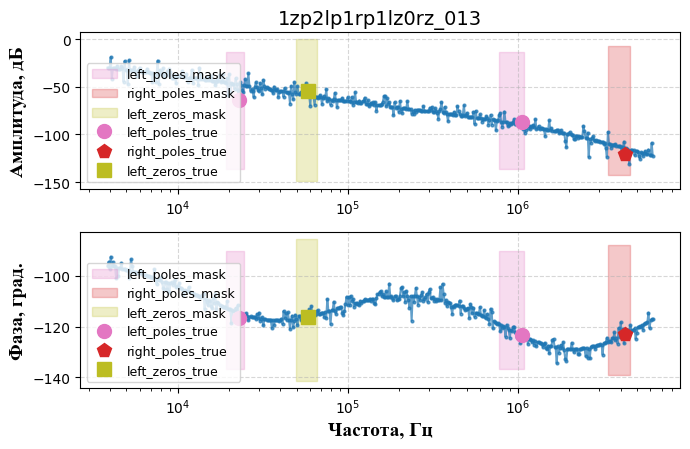

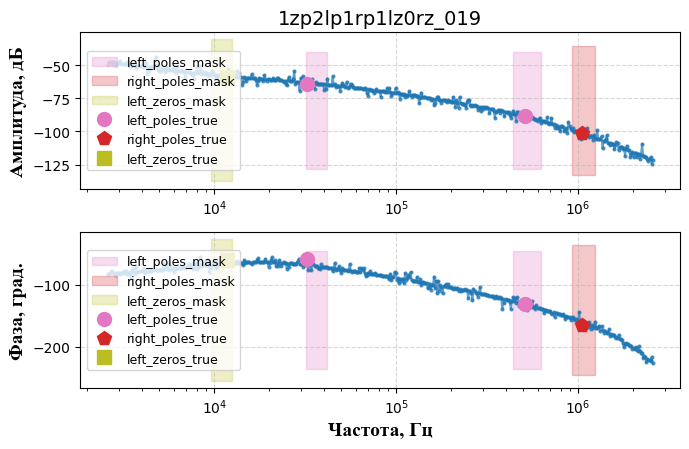

In [36]:
for data, zeros_poles, predictions, sample_file_name in zip(
    data_list,
    zeros_poles_list,
    predictions_list,
    sample_file_name_list
    ):
    if not positions_flag:
        zeros_poles_positions = zeros_poles_freq_to_positions(
            zeros_poles_freq_dict=zeros_poles,
            freq=data[0,:]
            )
    else:
        zeros_poles_positions = zeros_poles.copy()
    
    plot_responses(
        plot_config=PLOT_CONFIG,
        data=data,
        title=sample_file_name,
        regions=predictions,
        zeros_poles_positions=zeros_poles_positions,
        #save_path=f'usecases/test_samples/experiments_13_May_2026/pdf/{sample_file_name}.pdf'
        )

# Выделение координат центра масок

Проверка функции на выдуманном примере.

In [37]:
tmp = np.array([[0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0],
                [0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1]], dtype=np.float32)
print(tmp.shape)
positions, filtered_mask, num_regions_before, num_regions_after = mask_postprocess(
    mask=tmp,
    keys=['left_poles', 'right_poles'],
    M=5
    )
freq = data[0, :]

print('Coordinates:', positions)
print('Input Mask :\n', tmp)
print('Number of Regions:\n', num_regions_before)
print('Output Mask:\n', filtered_mask)
print('Number of Regions:\n', num_regions_after)

(2, 17)
Coordinates: {'left_poles': array([4]), 'right_poles': array([ 4, 14])}
Input Mask :
 [[0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.]
 [0. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1.]]
Number of Regions:
 [3 3]
Output Mask:
 [[0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]]
Number of Regions:
 [1 2]


Сравнение.

In [38]:
empty_sym = "-"

table_rows = []
freq_estim_list = []

In [39]:
for data, zeros_poles, predictions, sample_file_name in zip(
    data_list,
    zeros_poles_list,
    predictions_list,
    sample_file_name_list
):
    positions, _, _, _ = mask_postprocess(
        mask=predictions,
        keys=zeros_poles.keys(),
        M=model_log['metadata']['model']['mask_halfwindow']
    )
    
    freq = data[0, :]
    
    freq_estim_dict = {}        
    
    for key, val in positions.items():
        freq_estim_dict[key] = freq[val]
    
    freq_estim_list.append(freq_estim_dict)

    # Iterate directly over the keys (e.g., 'left_poles', 'right_poles').
    for key in positions:
        
        # 1. Convert to float (required for np.nan).
        estim_idx_all = np.array(positions[key], dtype=float)
        
        if positions_flag or len(zeros_poles[key]) == 0:
            target_idx_all = np.array(np.sort(zeros_poles[key]), dtype=float)
        else:    
            differences = np.abs(freq - np.array(zeros_poles[key])[:, None])
            target_idx_all = np.array(differences.argmin(axis=1).tolist(), dtype=float)
                    
        # 2. Initialize aligned variables (in case lengths are already equal).
        estim_idx_all_aligned = estim_idx_all.copy()
        target_idx_all_aligned = target_idx_all.copy()
        # 3. Align if lengths differ.
        if len(estim_idx_all) != len(target_idx_all):

            if len(estim_idx_all) > len(target_idx_all):
                # ESTIM is LONGER. We need to align TARGET to match ESTIM's length.
                target_idx_all_aligned = np.full(len(estim_idx_all), np.nan)
                
                # Iterate over the SHORTER array (target).
                for target_val in target_idx_all:
                    # Find the closest index in the LONGER array (estim).
                    closest_idx = np.argmin(np.abs(estim_idx_all - target_val))
                    target_idx_all_aligned[closest_idx] = target_val
                    
            else:
                # TARGET is LONGER. We need to align ESTIM to match TARGET's length.
                estim_idx_all_aligned = np.full(len(target_idx_all), np.nan)
                
                # Iterate over the SHORTER array (estim).
                for estim_val in estim_idx_all:
                    # Find the closest index in the LONGER array (target).
                    closest_idx = np.argmin(np.abs(target_idx_all - estim_val))
                    estim_idx_all_aligned[closest_idx] = estim_val

        for estim_idx, target_idx in zip(estim_idx_all_aligned, target_idx_all_aligned):
            if (not np.isnan(estim_idx)) and (not np.isnan(target_idx)):
                estim_val = float(freq[int(estim_idx)])
                target_val = float(freq[int(target_idx)])
            
                err_rel_val = np.abs(target_val - estim_val) / target_val
            else:
                err_rel_val = None
                if np.isnan(estim_idx):
                    target_val = float(freq[int(target_idx)])
                    estim_val = None
                if np.isnan(target_idx):
                    estim_val = float(freq[int(estim_idx)])
                    target_val = None
        
            table_rows.append({
                'sample_file': str(sample_file_name),
                'position': str(key),
                'estim': f"{estim_val:.0f}" if estim_val is not None else empty_sym,
                'target': f"{target_val:.0f}" if target_val is not None else empty_sym,
                'err_rel': f"{err_rel_val * 100:.2f}" if err_rel_val is not None else empty_sym
            })

Печать таблицы.

In [40]:
# Define column headers and dynamic widths based on data.
headers = ['Sample File', 'Object', 'Estim. Freq, Hz', 'Target Freq, Hz', 'Error, %']
col_widths = [
    max(len(headers[0]), max((len(row['sample_file']) for row in table_rows), default=0)),
    max(len(headers[1]), max((len(row['position']) for row in table_rows), default=0)),
    max(len(headers[2]), max((len(row['estim']) for row in table_rows), default=0)),
    max(len(headers[3]), max((len(row['target']) for row in table_rows), default=0)),
    max(len(headers[4]), max((len(row['err_rel']) for row in table_rows), default=0))
]

header_str = " | ".join(f"{h:<{w}}" for h, w in zip(headers, col_widths))
print(header_str)
print("-" * len(header_str))

for row in table_rows:
    #if row['estim'] != empty_sym and row['target'] != empty_sym:
    row_str = " | ".join([
        f"{row['sample_file']:<{col_widths[0]}}",
        f"{row['position']:<{col_widths[1]}}",
        f"{row['estim']:<{col_widths[2]}}",
        f"{row['target']:<{col_widths[3]}}",
        f"{row['err_rel']:<{col_widths[4]}}"
    ])
    print(row_str)

Sample File         | Object      | Estim. Freq, Hz | Target Freq, Hz | Error, %
--------------------------------------------------------------------------------
0zp0lp1rp2lz1rz_078 | right_poles | 755362          | 744592          | 1.45    
0zp0lp1rp2lz1rz_078 | left_zeros  | 20837           | 19393           | 7.45    
0zp0lp1rp2lz1rz_078 | left_zeros  | 142768          | 153397          | 6.93    
0zp0lp1rp2lz1rz_078 | right_zeros | 3041            | 3041            | 0.00    
0zp1lp0rp0lz1rz_028 | left_poles  | 485222          | 502183          | 3.38    
0zp1lp0rp0lz1rz_028 | right_zeros | 12496           | 12283           | 1.73    
0zp2lp1rp1lz0rz_022 | left_poles  | 3158            | 3322            | 4.93    
0zp2lp1rp1lz0rz_022 | left_poles  | -               | 48515           | -       
0zp2lp1rp1lz0rz_022 | right_poles | 15940           | 15779           | 1.02    
0zp2lp1rp1lz0rz_022 | left_zeros  | 42107           | 33703           | 24.93   
0zp2lp1rp1lz0rz_035 | left_p

In [41]:
freq_estim_list

[{'left_poles': array([], dtype=float64),
  'right_poles': array([755362.39217479]),
  'left_zeros': array([ 20837.01199804, 142768.01363914]),
  'right_zeros': array([3041.16487958])},
 {'left_poles': array([485221.51847068]),
  'right_poles': array([], dtype=float64),
  'left_zeros': array([], dtype=float64),
  'right_zeros': array([12495.51280726])},
 {'left_poles': array([3157.760323]),
  'right_poles': array([15939.9387053]),
  'left_zeros': array([42106.69331538]),
  'right_zeros': array([], dtype=float64)},
 {'left_poles': array([  7092.94003463, 455503.74062273]),
  'right_poles': array([237801.08223518]),
  'left_zeros': array([68992.15519579]),
  'right_zeros': array([], dtype=float64)},
 {'left_poles': array([], dtype=float64),
  'right_poles': array([1993848.3376757]),
  'left_zeros': array([  35255.60399055, 1010656.76468018]),
  'right_zeros': array([14314.76817714])},
 {'left_poles': array([8935.50695442]),
  'right_poles': array([], dtype=float64),
  'left_zeros': array

Тестовый пример

In [42]:
sample_file_name = 'test'

positions = {
  'left_poles': [198],
  'right_poles': [2, 5],
  'left_zeros': [220],
  'right_zeros': [5]
  }

zeros_poles = {
  'left_poles': [88, 298],
  'right_poles': [4],
  'left_zeros': [210, 330],
  'right_zeros': []
  }